# Repair Results Analysis

This notebook loads repair results from SQLite databases and generates summary statistics and visualizations.


In [42]:
import os
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [43]:
%matplotlib inline

In [44]:
target_db = 'targets.db'

In [45]:
sources_dbs = ["repair_results_claude_claude-sonnet-4-20250514_targets.db",
               "repair_results_gemini_gemini-2.5-flash-preview-05-20_targets.db",
               "repair_results_gemini_gemini-2.5-pro-preview-05-06_targets.db",
               "repair_results_openai_o3-2025-04-16_targets.db",
               "repair_results_openai_o4-mini-2025-04-16_targets.db"
               ]

In [46]:
import sqlite3
conn = sqlite3.connect(target_db)
df_cases = pd.read_sql(
    "SELECT id, num_nonterminals, nonterminal_prob, loop_prob, mutation_depth, parser_size, corrupted_symbol_count FROM cases",
    conn
)

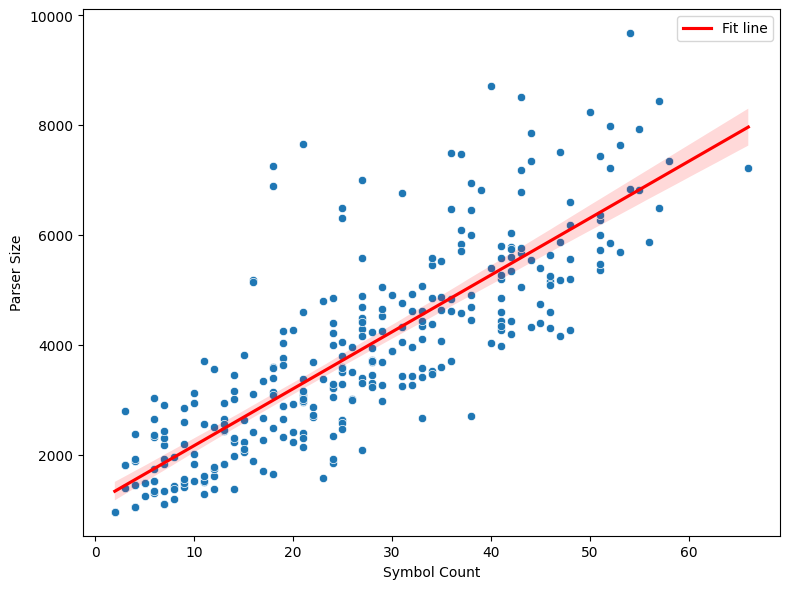

In [47]:

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_cases, x='corrupted_symbol_count', y='parser_size')
sns.regplot(data=df_cases, x='corrupted_symbol_count', y='parser_size', scatter=False, color='red', label='Fit line')
plt.legend()
plt.xlabel('Symbol Count')
plt.ylabel('Parser Size')
plt.tight_layout()


/var/folders/4p/mcvjxqjj0f32176nf_3wv1gc0000gt/T/ipykernel_544/3084036635.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_fixes, x="model", y="fix_count", palette="tab10")


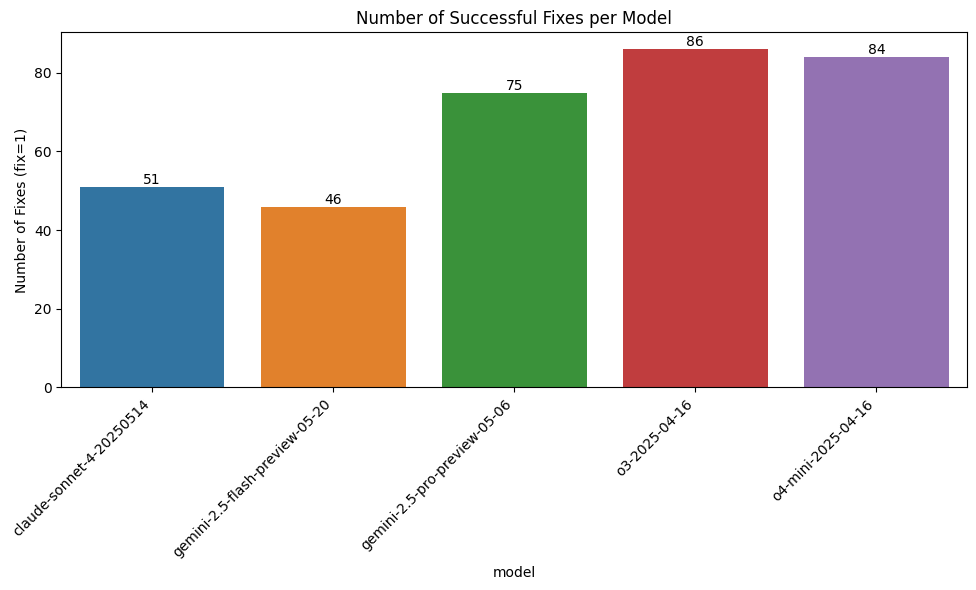

In [48]:
counts = []
for db_path in sources_dbs:
    model = os.path.basename(db_path).removeprefix("repair_results_").removesuffix("_targets.db").split("_")[1]
    conn = sqlite3.connect(db_path)
    cnt = pd.read_sql(
        "SELECT COUNT(*) AS fixes FROM repair_results WHERE fix = 1",
        conn
    )["fixes"].iloc[0]
    conn.close()
    counts.append({"model": model, "fix_count": cnt})

df_fixes = pd.DataFrame(counts)

plt.figure(figsize=(10, 6))
sns.barplot(data=df_fixes, x="model", y="fix_count", palette="tab10")
# Annotate fix counts on top of each bar
for i, v in enumerate(df_fixes['fix_count']):
    plt.text(i, v, str(v), ha='center', va='bottom')
plt.xticks(rotation=45, ha="right")
plt.ylabel("Number of Fixes (fix=1)")
plt.title("Number of Successful Fixes per Model")
plt.tight_layout()

/var/folders/4p/mcvjxqjj0f32176nf_3wv1gc0000gt/T/ipykernel_544/2581659869.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_okcases, x='model', y='corrupted_symbol_count', palette='tab10')


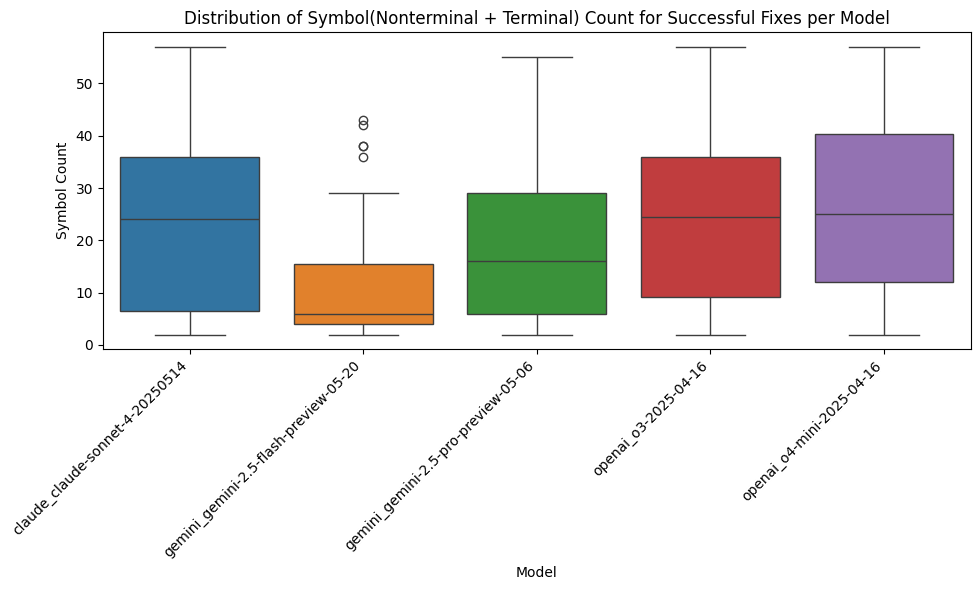

In [49]:
# Distribution of corrupted_symbol_count for successful fixes per model
records = []
for db_path in sources_dbs:
    model = os.path.basename(db_path).removeprefix('repair_results_').removesuffix('_targets.db')
    conn = sqlite3.connect(db_path)
    df_res = pd.read_sql(
        'SELECT case_id, fix FROM repair_results',
        conn
    )
    conn.close()
    df_ok = df_res[df_res['fix'] == 1].merge(
        df_cases[['id', 'corrupted_symbol_count']], left_on='case_id', right_on='id'
    )
    for cs in df_ok['corrupted_symbol_count']:
        records.append({'model': model, 'corrupted_symbol_count': cs})

df_okcases = pd.DataFrame(records)

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_okcases, x='model', y='corrupted_symbol_count', palette='tab10')
plt.xticks(rotation=45, ha='right')
plt.xlabel('Model')
plt.ylabel('Symbol Count')
plt.title('Distribution of Symbol(Nonterminal + Terminal) Count for Successful Fixes per Model')
plt.tight_layout()


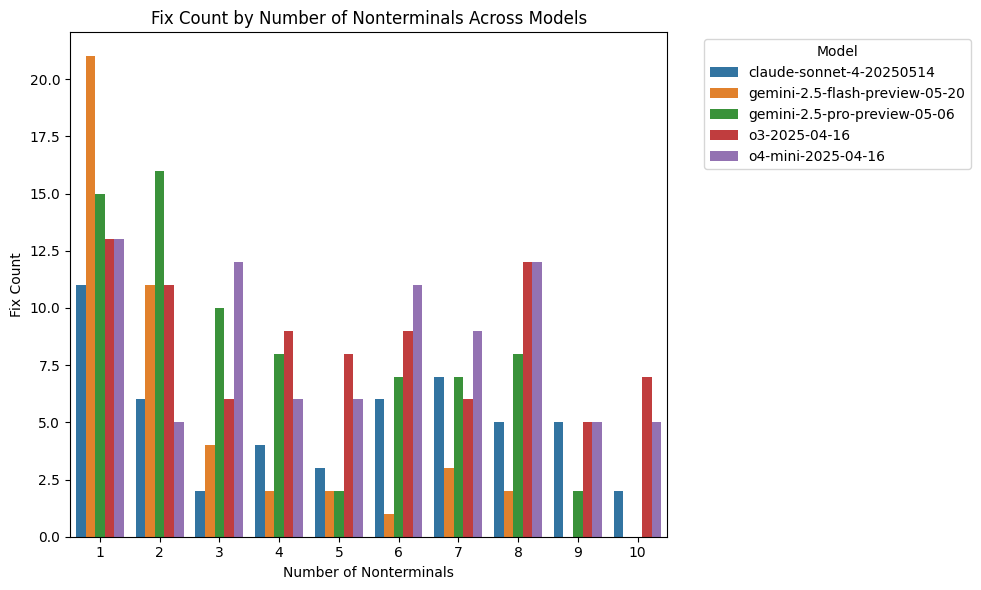

In [50]:
# Bar plot of fix counts by number of nonterminals across all models
records = []
for db_path in sources_dbs:
    model = os.path.basename(db_path).removeprefix('repair_results_').removesuffix('_targets.db').split('_')[1]
    conn = sqlite3.connect(db_path)
    df_res = pd.read_sql('SELECT case_id, fix FROM repair_results', conn)
    conn.close()
    df_ok = df_res[df_res['fix'] == 1].merge(df_cases[['id','num_nonterminals']], left_on='case_id', right_on='id')
    counts = df_ok['num_nonterminals'].value_counts().sort_index()
    for num_nt, cnt in counts.items():
        records.append({'model': model, 'num_nonterminals': num_nt, 'fix_count': cnt})

df_nt_fixes = pd.DataFrame(records)

plt.figure(figsize=(10, 6))
sns.barplot(data=df_nt_fixes, x='num_nonterminals', y='fix_count', hue='model')
plt.xlabel('Number of Nonterminals')
plt.ylabel('Fix Count')
plt.title('Fix Count by Number of Nonterminals Across Models')
plt.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()


/var/folders/4p/mcvjxqjj0f32176nf_3wv1gc0000gt/T/ipykernel_544/1584322459.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_model, x='num_nonterminals', y='fix_count', palette='viridis')


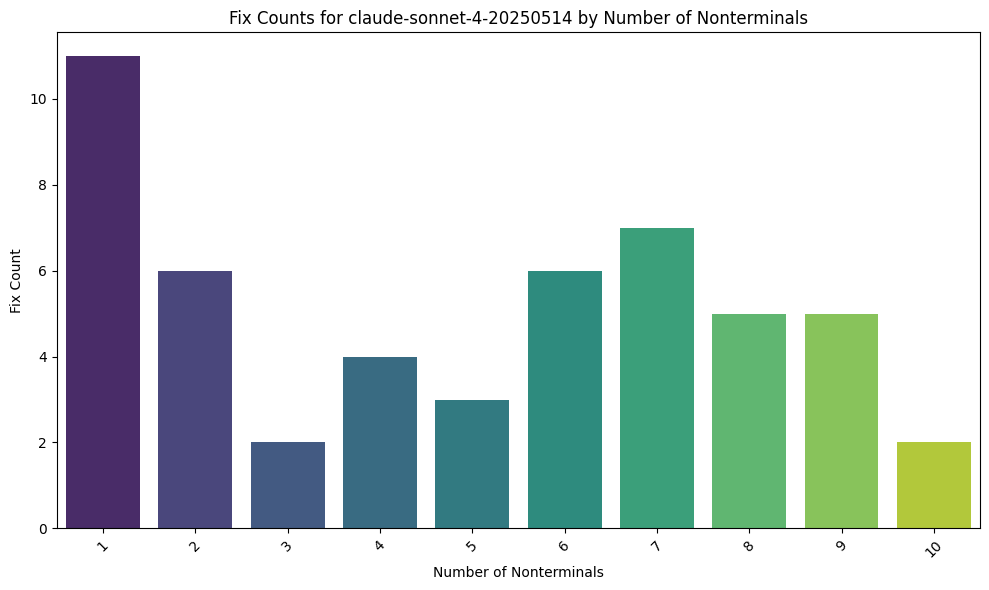

/var/folders/4p/mcvjxqjj0f32176nf_3wv1gc0000gt/T/ipykernel_544/1584322459.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_model, x='num_nonterminals', y='fix_count', palette='viridis')


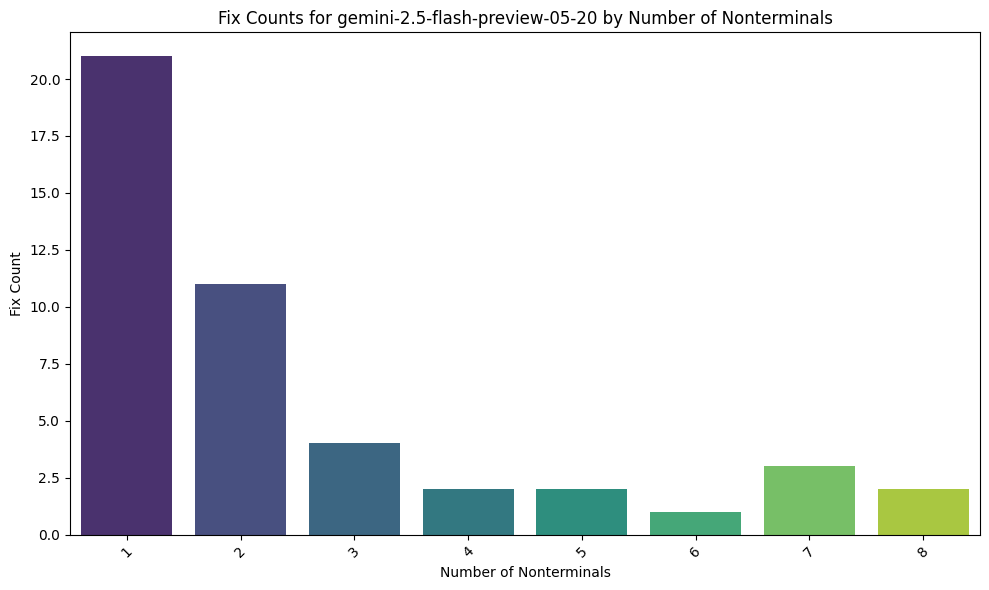

/var/folders/4p/mcvjxqjj0f32176nf_3wv1gc0000gt/T/ipykernel_544/1584322459.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_model, x='num_nonterminals', y='fix_count', palette='viridis')


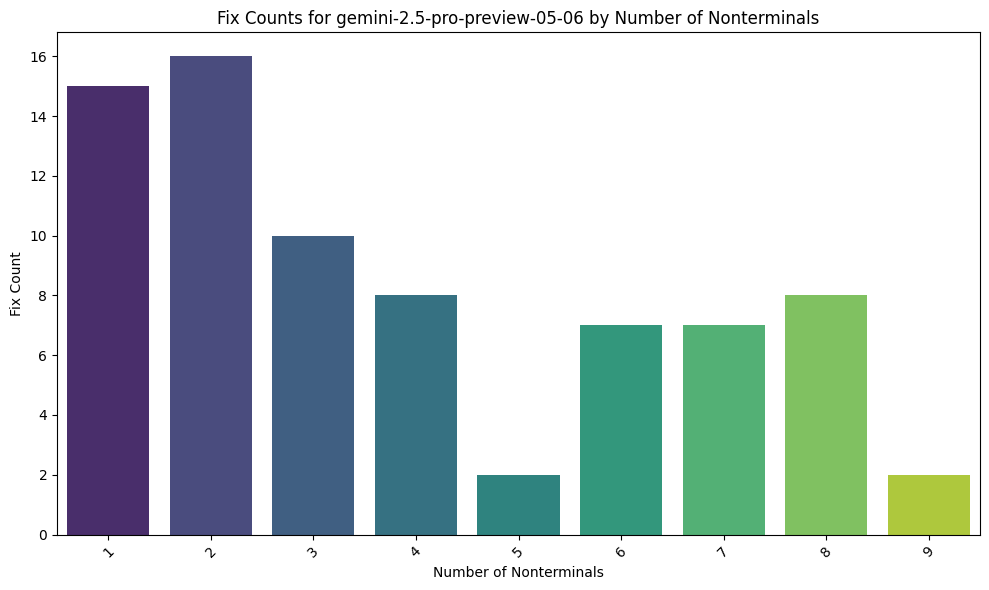

/var/folders/4p/mcvjxqjj0f32176nf_3wv1gc0000gt/T/ipykernel_544/1584322459.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_model, x='num_nonterminals', y='fix_count', palette='viridis')


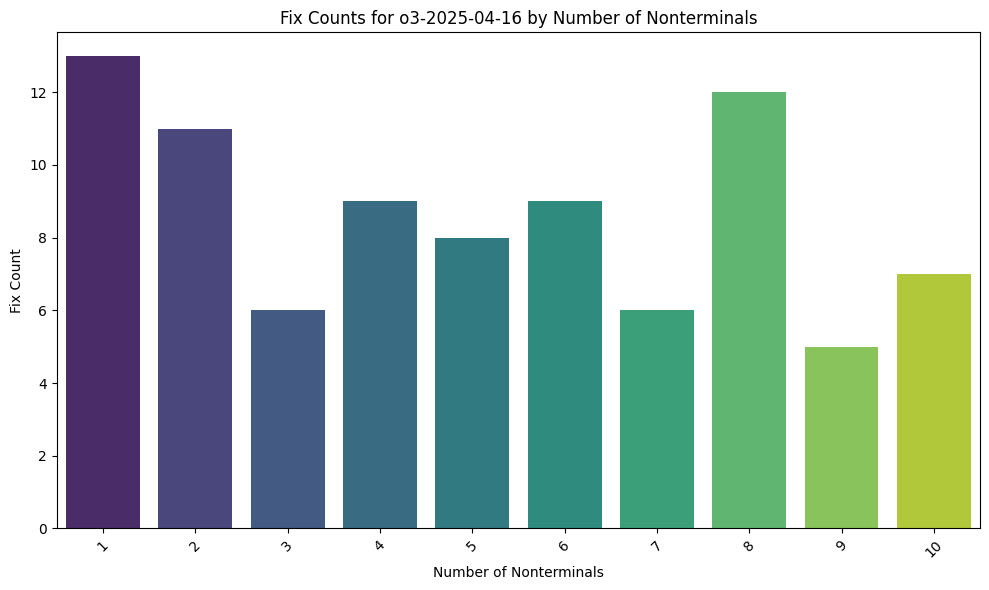

/var/folders/4p/mcvjxqjj0f32176nf_3wv1gc0000gt/T/ipykernel_544/1584322459.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_model, x='num_nonterminals', y='fix_count', palette='viridis')


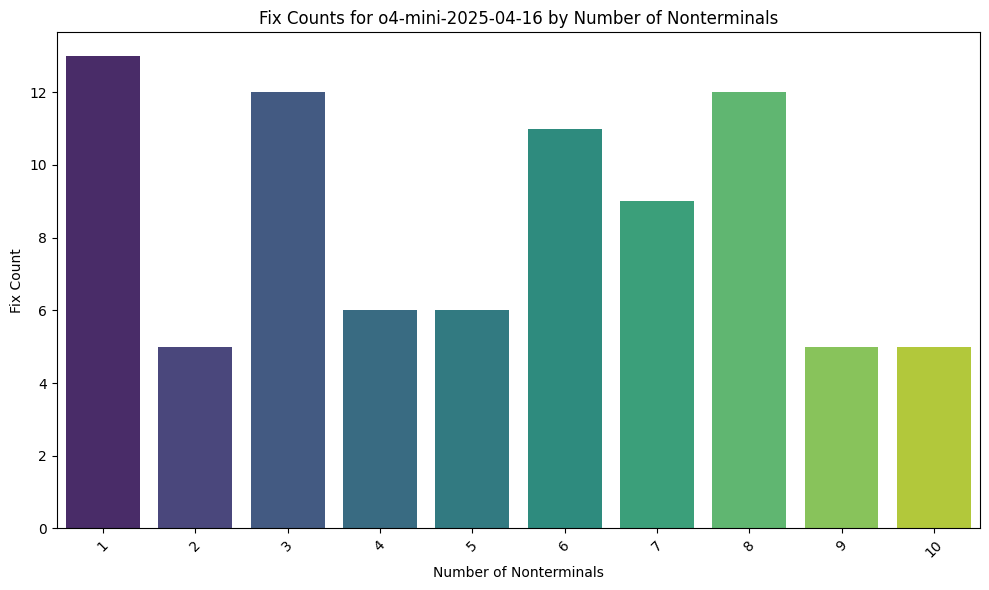

In [51]:
# generate chart for each model with fix counts by number of nonterminals
for model in df_nt_fixes['model'].unique():
    df_model = df_nt_fixes[df_nt_fixes['model'] == model]
    plt.figure(figsize=(10, 6))
    sns.barplot(data=df_model, x='num_nonterminals', y='fix_count', palette='viridis')
    plt.title(f'Fix Counts for {model} by Number of Nonterminals')
    plt.xlabel('Number of Nonterminals')
    plt.ylabel('Fix Count')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

/var/folders/4p/mcvjxqjj0f32176nf_3wv1gc0000gt/T/ipykernel_544/169938833.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_mut, x='num_nonterminals', y='mutation_depth', palette='tab10')


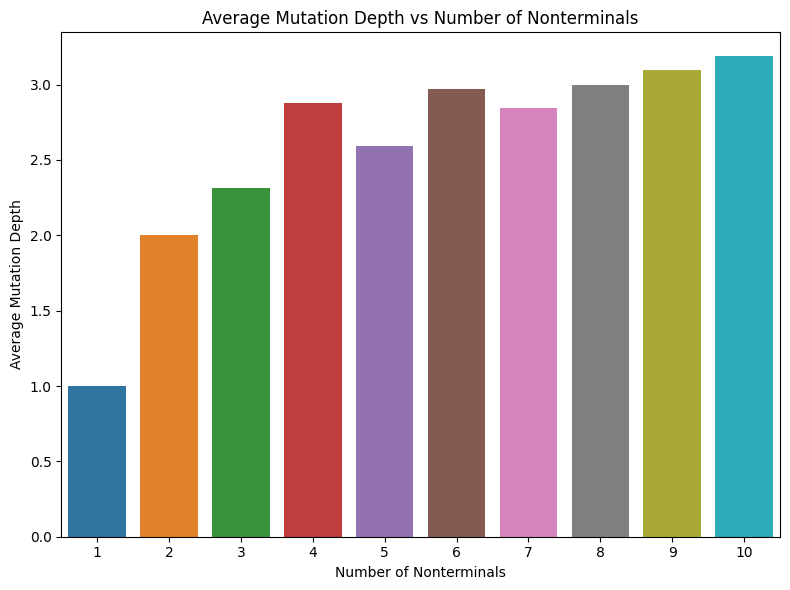

In [52]:
# Bar plot of average mutation_depth vs num_nonterminals
avg_mut = df_cases.groupby('num_nonterminals')['mutation_depth'].mean().reset_index()
plt.figure(figsize=(8, 6))
sns.barplot(data=avg_mut, x='num_nonterminals', y='mutation_depth', palette='tab10')
plt.xlabel('Number of Nonterminals')
plt.ylabel('Average Mutation Depth')
plt.title('Average Mutation Depth vs Number of Nonterminals')
plt.tight_layout()


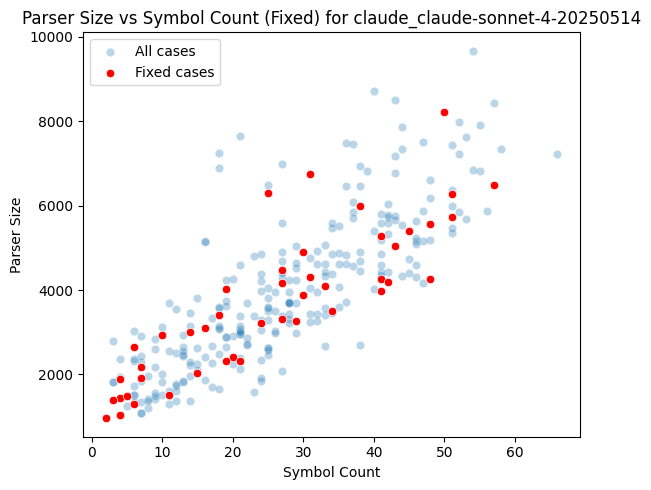

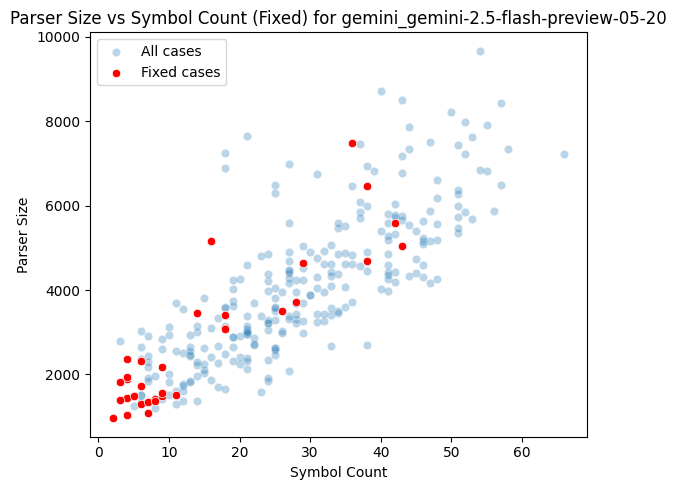

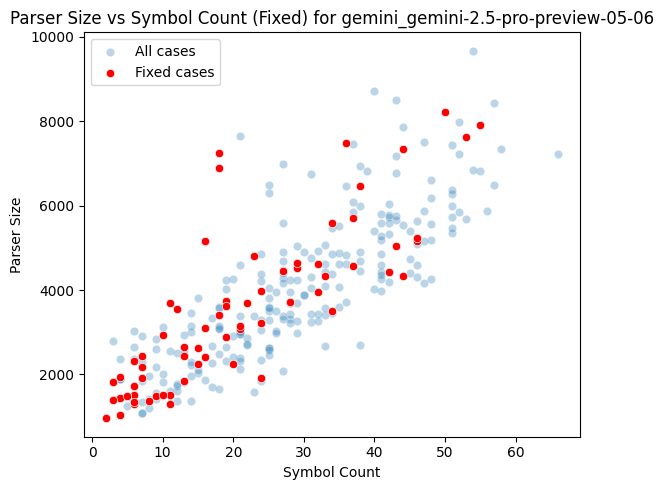

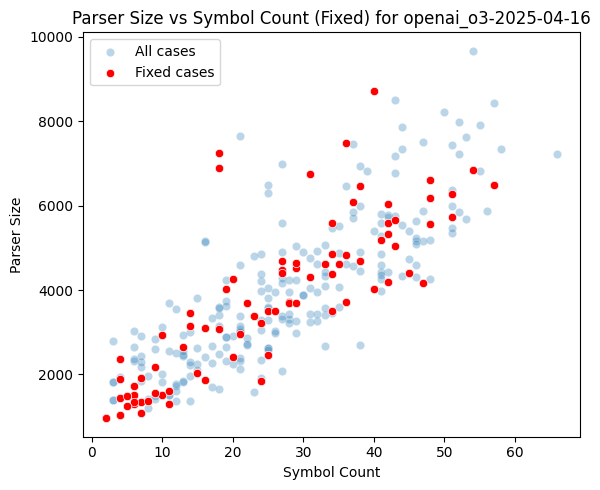

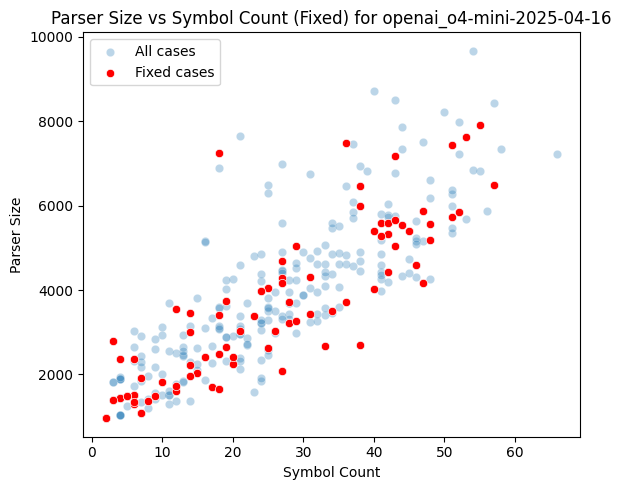

In [53]:
# Scatter plot of parser_size vs corrupted_symbol_count, highlighting fixed cases per model
for db_path in sources_dbs:
    model = os.path.basename(db_path).removeprefix('repair_results_').removesuffix('_targets.db')
    conn = sqlite3.connect(db_path)
    df_res = pd.read_sql(
        'SELECT case_id, fix FROM repair_results', conn
    )
    conn.close()
    fixed = df_res[df_res['fix'] == 1]['case_id']
    plt.figure(figsize=(6, 5))
    sns.scatterplot(data=df_cases, x='corrupted_symbol_count', y='parser_size', alpha=0.3, label='All cases')
    sns.scatterplot(data=df_cases[df_cases['id'].isin(fixed)], 
                    x='corrupted_symbol_count', y='parser_size', color='red', label='Fixed cases')
    plt.title(f'Parser Size vs Symbol Count (Fixed) for {model}')
    plt.xlabel('Symbol Count')
    plt.ylabel('Parser Size')
    plt.legend()
    plt.tight_layout()


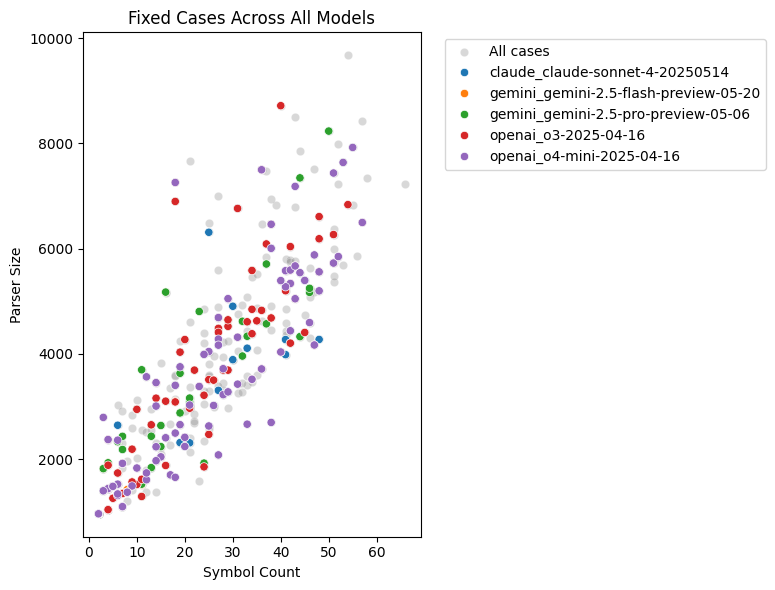

In [54]:
# Combined scatter plot of fixed cases across all models
records = []
for db_path in sources_dbs:
    model = os.path.basename(db_path).removeprefix('repair_results_').removesuffix('_targets.db')
    conn = sqlite3.connect(db_path)
    df_res = pd.read_sql('SELECT case_id, fix FROM repair_results', conn)
    conn.close()
    fixed_ids = df_res[df_res['fix'] == 1]['case_id']
    df_tmp = df_cases[df_cases['id'].isin(fixed_ids)].copy()
    df_tmp['model'] = model
    records.append(df_tmp)

df_fixed_all = pd.concat(records, ignore_index=True)

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_cases, x='corrupted_symbol_count', y='parser_size', color='gray', alpha=0.3, label='All cases')
sns.scatterplot(data=df_fixed_all, x='corrupted_symbol_count', y='parser_size', hue='model')
plt.xlabel('Symbol Count')
plt.ylabel('Parser Size')
plt.title('Fixed Cases Across All Models')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
